In [5]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

df_master = pd.read_csv('master_final.csv')

with open('/content/mfcc_data.pkl', 'rb') as f:
    mfcc_dict = pickle.load(f)

In [6]:
# dataframe setting

mfcc_vec_cols = [f'mfcc_feat_{i}' for i in range(50)]
mfcc_df = pd.DataFrame(mfcc_dict['mfcc_features'], columns=mfcc_vec_cols)
mfcc_df['Video_ID'] = mfcc_dict['filename']

# Clean the Video_ID to ensure consistency and proper matching

df_master['Video_ID'] = df_master['Video_ID'].astype(str).str.replace('.mp4', '', regex=False).str.strip()
mfcc_df['Video_ID'] = mfcc_df['Video_ID'].astype(str).str.replace('.mp4', '', regex=False).str.strip()

# final marge
df = pd.merge(df_master, mfcc_df, on='Video_ID', how='inner')
print(f"marge done : {len(df.columns)}")

# data cleaning
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

marge done : 62


,Video_ID,label,similarity,WER,correct_words_#,mfcc_prediction,mfcc_probability,mfcc_svm_decision_score,mfcc_feat_0,mfcc_feat_1,...,mfcc_feat_40,mfcc_feat_41,mfcc_feat_42,mfcc_feat_43,mfcc_feat_44,mfcc_feat_45,mfcc_feat_46,mfcc_feat_47,mfcc_feat_48,mfcc_feat_49
0,0_00000,0,8.146640,100.000000,0,1,0.713175,0.782946,-236.617630,92.429817,...,1789.505629,3464.272444,1735.006472,15.691054,17.774254,21.079627,19.397982,18.500947,19.722032,18.300492
1,0_00001,0,76.973684,42.105263,23,0,0.968595,-3.215874,-407.668823,157.306702,...,2151.846035,4112.542378,2831.515993,17.229187,11.051055,15.226733,16.610441,17.618802,20.712544,30.284682
2,0_00002,0,70.625000,58.823529,15,0,0.811473,-1.412783,-272.981842,84.132591,...,1972.243099,3600.777838,1588.110604,23.540508,16.790347,18.396294,17.768354,17.482005,20.647386,16.886003
3,0_00003,0,74.183976,45.945946,20,1,0.553677,0.140833,-333.608978,99.893410,...,1788.165107,3605.878995,1670.140595,19.345279,14.418756,19.533040,17.153365,17.736857,22.227197,16.922992
4,0_00004,0,58.823529,81.250000,5,1,0.794505,1.190282,-350.967590,128.054321,...,1160.019862,2186.167636,1479.830982,21.573779,15.305312,18.890804,16.583260,18.213436,15.842405,15.238705


In [8]:
# set up the experiments in features
experiments = {
    "E21": mfcc_vec_cols + ['WER', 'similarity'],
    "E22": mfcc_vec_cols + ['WER', 'mfcc_svm_decision_score'],
    "E23": ['WER', 'similarity', 'mfcc_svm_decision_score'],
    "E24":['mfcc_prediction','mfcc_probability', 'mfcc_svm_decision_score'],
    "E25": mfcc_vec_cols + ['similarity', 'WER', 'correct_words_#',
                            'mfcc_probability', 'mfcc_svm_decision_score','mfcc_prediction']
}
results = []

In [9]:
for exp_name, features in experiments.items():

    # to ensure that all required features are present in the actual dataset table.
    available_features = [f for f in features if f in df.columns]

    # set x ,y
    X = df[available_features]
    y = df['label']

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
        )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    results.append({
        "Experiment": exp_name,
        "Accuracy": np.mean(acc_scores),
        "F1": np.mean(f1_scores)
    })

    print(f"{exp_name} | Acc: {np.mean(acc_scores):.3f} | F1: {np.mean(f1_scores):.3f}")

results_df = pd.DataFrame(results)
results_df

E21 | Acc: 0.933 | F1: 0.941
E22 | Acc: 0.936 | F1: 0.944
E23 | Acc: 0.891 | F1: 0.905
E24 | Acc: 0.714 | F1: 0.742
E25 | Acc: 0.938 | F1: 0.945


,Experiment,Accuracy,F1
0,E21,0.933044,0.941368
1,E22,0.936200,0.944018
2,E23,0.891342,0.904509
3,E24,0.714415,0.741900
4,E25,0.937647,0.945223


In [10]:
best_exp = results_df.sort_values(by='F1', ascending=False).iloc[0]['Experiment']
print("Best Experiment:", best_exp)

features = experiments[best_exp]
features = [f for f in features if f in df.columns]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Best Experiment: E25


In [11]:
params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [12]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9375410913872453
F1: 0.945054945054945

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       679
           1       0.92      0.97      0.95       842

    accuracy                           0.94      1521
   macro avg       0.94      0.93      0.94      1521
weighted avg       0.94      0.94      0.94      1521



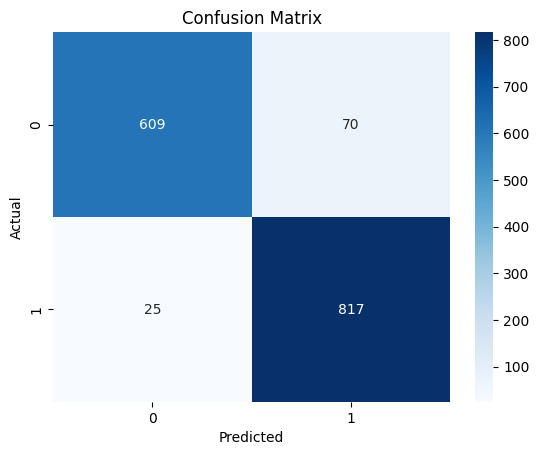

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()